## Library

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, Callback, ReduceLROnPlateau

## Load Dataset

In [58]:
df = pd.read_csv("dataset_sigaleh_Final.csv")

## Filter Data

In [60]:
df = df[
    (df['Komoditas (Rp)'] == 'Bawang Merah') &
    (df['Wilayah'] == 'Bukittinggi')
]

## Preprocessing

In [61]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values(by='Tanggal')
df = df.reset_index(drop=True)

df = df.fillna(method='ffill')

/tmp/ipykernel_60154/3819647519.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


## Fitur

In [62]:
df['Harga_3Hari_Lalu'] = df['Harga'].shift(3)
df['Harga_7Hari_Lalu'] = df['Harga'].shift(7)

df['MA_7'] = df['Harga'].rolling(7).mean()

df = df.dropna()

## Fitur Final

In [63]:
features = df[[
    'Harga',
    'Suhu_Rata2_C',
    'Curah_Hujan_mm',
    'Harga_Kemarin',
    'Harga_Minggu_Lalu',
    'Harga_3Hari_Lalu',
    'Harga_7Hari_Lalu',
    'MA_7'
]]

## Sclaing

In [64]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)

## Sliding Window

In [66]:
window_size = 14

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

## Split Data

In [67]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

## Model LSTM

In [68]:
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = LSTM(64, return_sequences=True)(input_layer)
x = Dropout(0.2)(x)
x = LSTM(32)(x)
x = Dense(32, activation='relu')(x)

output = Dense(1)(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

## Callback

In [69]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Epoch {epoch+1} | Loss: {logs['loss']:.4f} | Val: {logs['val_loss']:.4f}")

## Training Model

In [70]:
history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler, CustomCallback()]
)

Epoch 1/60
59/63 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0206 - mae: 0.1390Epoch 1 | Loss: 0.0084 | Val: 0.0088
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0084 - mae: 0.0861 - val_loss: 0.0088 - val_mae: 0.1051 - learning_rate: 0.0010
Epoch 2/60
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0028 - mae: 0.0541Epoch 2 | Loss: 0.0027 | Val: 0.0050
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0027 - mae: 0.0526 - val_loss: 0.0050 - val_mae: 0.0727 - learning_rate: 0.0010
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0019 - mae: 0.0457Epoch 3 | Loss: 0.0019 | Val: 0.0031
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0019 - mae: 0.0438 - val_loss: 0.0031 - val_mae: 0.0573 - learning_rate: 0.0010
Epoch 4/60
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0014 - mae: 0.0382Epoch 4 | Loss: 0.0016 | Val: 0.0049
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0016 - mae: 0.0399 - val_loss: 0.0049 - val_mae: 0.0721 - learning_rate: 0.0010
Epoch 5/60
61/63

## Prediksi

In [71]:
pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


## Inverse Scaling

In [72]:
harga_min = scaler.data_min_[0]
harga_max = scaler.data_max_[0]

pred_inv = pred * (harga_max - harga_min) + harga_min
y_test_inv = y_test.reshape(-1,1) * (harga_max - harga_min) + harga_min

## Evaluasi

In [73]:
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))

mape = np.mean(
    np.abs((y_test_inv - pred_inv) / y_test_inv)
) * 100

accuracy = 100 - mape

mae_scaled = np.mean(np.abs(y_test - pred))

print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"Akurasi : {accuracy:.2f}%")
print(f"MAE (scaled) : {mae_scaled:.4f}")

RMSE : 1625.79
MAPE : 2.98%
Akurasi : 97.02%
MAE (scaled) : 0.1500


## Visualisasi

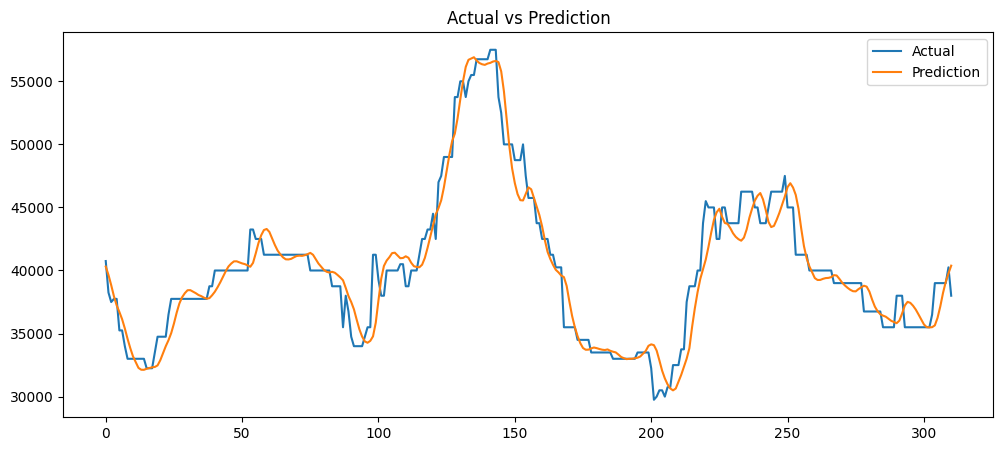

In [74]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(pred_inv, label='Prediction')
plt.legend()
plt.title('Actual vs Prediction')
plt.show()

## Save Model

In [75]:
model.save("model_lstm.keras")

import joblib
joblib.dump(scaler, "scaler.save")

['scaler.save']